# Week 7: 딥러닝 기초 (2026-05-11)

## 1. 실습 개요
- 인공 신경망의 기본 원리 이해
- PyTorch 기초 및 MLP 구현

In [147]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import random

from sklearn.model_selection import  train_test_split
from sklearn.metrics import *
from sklearn.preprocessing import  StandardScaler, MinMaxScaler

import torch
from torch import nn
from torch.utils.data import  DataLoader, TensorDataset
from torch.optim import Adam
from torchvision import datasets
from torchvision.transforms import ToTensor

from config import CONTENT_DIR

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams['font.family'] = 'NanumGothic' # Windows
# plt.rcParams['font.family'] = 'AppleGothic' # Mac
plt.rcParams['axes.unicode_minus'] = False

In [39]:
def make_DataSet(X_train, X_val, y_train, y_val, batch_size = 32) :
    # batch_size : 모델이 한 번에 몇 개의 데이터를 보고 학습할지 정하는 값

    # 데이터 텐서로 변환
    X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
    y_train_tensor = torch.tensor(y_train.values, dtype=torch.float32).view(-1, 1)
    X_val_tensor = torch.tensor(X_val, dtype=torch.float32)
    y_val_tensor = torch.tensor(y_val.values, dtype=torch.float32).view(-1, 1)

    # TensorDataset 생성 : 텐서 데이터셋으로 합치기
    train_dataset = TensorDataset(X_train_tensor, y_train_tensor)

    # DataLoader 생성
    train_loader = DataLoader(train_dataset, batch_size = batch_size, shuffle = False)

    return train_loader, X_val_tensor, y_val_tensor

def train(dataloader, model, loss_fn, optimizer, device):
    size = len(dataloader.dataset)
    num_batches = len(dataloader)
    tr_loss = 0
    model.train()                                           # 훈련 모드로 설정
    for batch, (X, y) in enumerate(dataloader):
        X, y = X.to(device), y.to(device)


        pred = model(X)
        loss = loss_fn(pred, y)
        tr_loss += loss


        loss.backward()
        optimizer.step()
        optimizer.zero_grad()

    tr_loss /= num_batches

    return tr_loss.item()

def evaluate(X_val_tensor, y_val_tensor, model, loss_fn, device):
    model.eval()

    with torch.no_grad():
        X, y = X_val_tensor.to(device), y_val_tensor.to(device)
        pred = model(X)
        eval_loss = loss_fn(pred, y).item()

    return eval_loss, pred

device = "cuda" if torch.cuda.is_available() else "cpu"
def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed) # 멀티 GPU 사용 시
    torch.backends.cudnn.deterministic = True # 연산 결과 고정
    torch.backends.cudnn.benchmark = False # 최적화 알고리즘 고정
# 행운의 숫자 하나를 골라 시드를 고정합니다.
set_seed(42)

def dl_learning_curve(tr_loss_list, val_loss_list):
    epochs = range(1, len(tr_loss_list) + 1)

    plt.figure(figsize=(7, 4))
    plt.plot(epochs, tr_loss_list, label="train_loss", marker=".")
    plt.plot(epochs, val_loss_list, label="val_loss", marker=".")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()


Epoch 50, train loss : 17.873444, val loss : 22.880840
Epoch 100, train loss : 11.546101, val loss : 16.558586
Epoch 150, train loss : 8.730509, val loss : 14.248583
Epoch 200, train loss : 7.615715, val loss : 13.706675


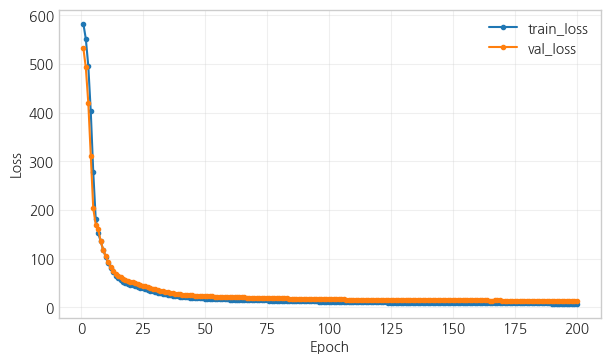

MSE : 13.706675
MAE : 2.689919
MAPE : 0.152963


In [62]:
path = f"{CONTENT_DIR}/boston.csv"
df = pd.read_csv(path)
df.head()

target = 'medv'
X = df.drop(target, axis=1)
y = df[target]

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=2026
)

scaler = MinMaxScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)


train_loader, X_val_ts, y_val_ts = make_DataSet(
    X_train, X_val, y_train, y_val, batch_size=32
)

n_feature = X.shape[1]

# 모델 구조 설계
model1 = nn.Sequential(
    nn.Linear(n_feature, 128),
    nn.ReLU(),
    
    nn.Linear(128, 64),
    nn.ReLU(),
    
    nn.Linear(64, 1)
).to(device)

loss_fn = nn.MSELoss()
optimizer = Adam(
    model1.parameters(), lr=0.001
)  

epochs = 200
tr_loss_list, val_loss_list = [], []

for t in range(1, epochs + 1):
    tr_loss = train(train_loader, model1, loss_fn, optimizer, device)
    val_loss, _ = evaluate(X_val_ts, y_val_ts, model1, loss_fn, device)
    
    tr_loss_list.append(tr_loss)
    val_loss_list.append(val_loss)
    if t % 50 == 0:
        print(f"Epoch {t}, train loss : {tr_loss:4f}, val loss : {val_loss:4f}")

dl_learning_curve(tr_loss_list, val_loss_list)

loss, pred = evaluate(X_val_ts, y_val_ts, model1, loss_fn, device)

mae = mean_absolute_error(y_val_ts.cpu().numpy(), pred.cpu().numpy())
mape = mean_absolute_percentage_error(y_val_ts.cpu().numpy(), pred.cpu().numpy())

print(f'MSE : {loss:4f}')
print(f'MAE : {mae:4f}')
print(f'MAPE : {mape:4f}')

Epoch 50, train loss : 1.190571, val loss : 2.111456
Epoch 100, train loss : 0.603134, val loss : 1.597895
Epoch 150, train loss : 0.468723, val loss : 1.722711


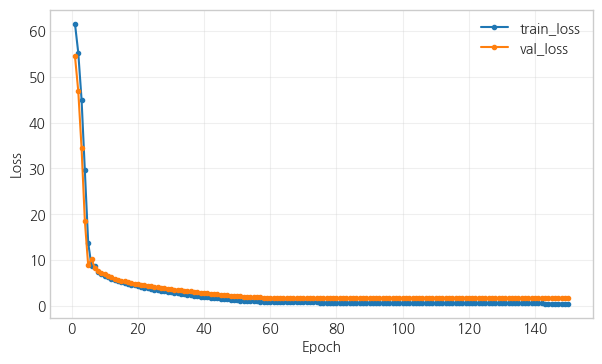

MSE : 1.722711
MAE : 1.066876
MAPE : 0.281227


In [67]:
path = CONTENT_DIR / "Carseats.csv"
df = pd.read_csv(path)
df.head()

target = 'Sales'
cat_cols = ['ShelveLoc', 'Education', 'Urban', 'US']
X = df.drop(target, axis = 1)
X = pd.get_dummies(X, columns = cat_cols, drop_first = True)
y = df.loc[:, target]

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=2026
)

scaler = MinMaxScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)



train_loader, X_val_ts, y_val_ts = make_DataSet(
    X_train, X_val, y_train, y_val, batch_size=32
)

n_feature = X.shape[1]

# 모델 구조 설계
model1 = nn.Sequential(
    nn.Linear(n_feature, 128),
    nn.ReLU(),
    
    nn.Linear(128, 64),
    nn.ReLU(),
    
    nn.Linear(64, 1)
).to(device)

loss_fn = nn.MSELoss()
optimizer = Adam(
    model1.parameters(), lr=0.001
)  

epochs = 150
tr_loss_list, val_loss_list = [], []

for t in range(1, epochs + 1):
    tr_loss = train(train_loader, model1, loss_fn, optimizer, device)
    val_loss, _ = evaluate(X_val_ts, y_val_ts, model1, loss_fn, device)
    
    tr_loss_list.append(tr_loss)
    val_loss_list.append(val_loss)
    if t % 50 == 0:
        print(f"Epoch {t}, train loss : {tr_loss:4f}, val loss : {val_loss:4f}")

dl_learning_curve(tr_loss_list, val_loss_list)

loss, pred = evaluate(X_val_ts, y_val_ts, model1, loss_fn, device)

mae = mean_absolute_error(y_val_ts.cpu().numpy(), pred.cpu().numpy())
mape = mean_absolute_percentage_error(y_val_ts.cpu().numpy(), pred.cpu().numpy())

print(f'MSE : {loss:4f}')
print(f'MAE : {mae:4f}')
print(f'MAPE : {mape:4f}')

Epoch 20, train loss : 0.411394, val loss : 0.418000
Epoch 40, train loss : 0.399408, val loss : 0.405855
Epoch 60, train loss : 0.391748, val loss : 0.399929
Epoch 80, train loss : 0.385035, val loss : 0.394051
Epoch 100, train loss : 0.379031, val loss : 0.392276


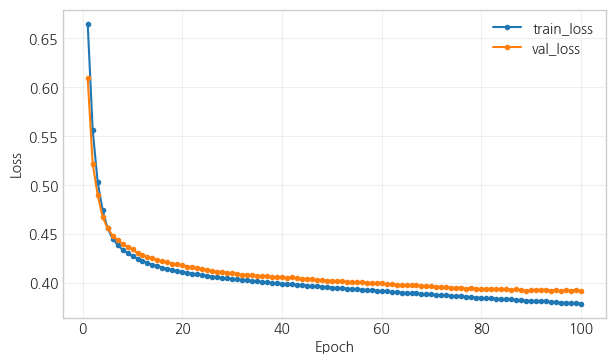

Accuracy: 0.8436

[Classification Report]
              precision    recall  f1-score   support

        Dead       0.84      0.91      0.88       108
    Survived       0.84      0.75      0.79        71

    accuracy                           0.84       179
   macro avg       0.84      0.83      0.83       179
weighted avg       0.84      0.84      0.84       179


[Confusion Matrix]
[[98 10]
 [18 53]]


In [95]:
path = CONTENT_DIR / 'titanic.csv'
df = pd.read_csv(path)
df.drop(['Age_scale1', 'AgeGroup', 'SibSp', 'Parch'], axis=1, inplace=True)

target = 'Survived'
X = pd.get_dummies(df.drop(target, axis=1), columns=['Sex', 'Embarked'], drop_first=True)
y = df[target]

X_train, X_val, y_train, y_val = train_test_split(X, y,
                                                  test_size=.2,
                                                  random_state=2026)

scaler = MinMaxScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)

train_loader, X_val_ts, y_val_ts = make_DataSet(
    X_train, X_val, y_train, y_val, batch_size=16
)

n_feature = X.shape[1]

# 모델 구조 설계
model1 = nn.Sequential(
    nn.Linear(n_feature, 64),
    nn.ReLU(),
    
    nn.Linear(64, 32),
    nn.ReLU(),
    
    nn.Linear(32, 16),
    nn.ReLU(),
    
    nn.Linear(16, 1),
    nn.Sigmoid()
).to(device)

loss_fn = nn.BCELoss()
optimizer = Adam(
    model1.parameters(), lr=0.001
)  

epochs = 100
tr_loss_list, val_loss_list = [], []

for t in range(1, epochs + 1):
    tr_loss = train(train_loader, model1, loss_fn, optimizer, device)
    val_loss, _ = evaluate(X_val_ts, y_val_ts, model1, loss_fn, device)
    
    tr_loss_list.append(tr_loss)
    val_loss_list.append(val_loss)
    if t % 20 == 0:
        print(f"Epoch {t}, train loss : {tr_loss:4f}, val loss : {val_loss:4f}")

dl_learning_curve(tr_loss_list, val_loss_list)

loss, pred = evaluate(X_val_ts, y_val_ts, model1, loss_fn, device)

y_pred_label = (pred >= 0.5).float()
# 텐서를 넘파이로 변환
y_true = y_val_ts.cpu().numpy()
y_pred = y_pred_label.cpu().numpy()
# 1. 정확도 출력
print(f"Accuracy: {accuracy_score(y_true, y_pred):.4f}")
# 2. 종합 리포트 (Precision, Recall, F1-score 포함)
print("\n[Classification Report]")
print(classification_report(y_true, y_pred, target_names=['Dead', 'Survived']))
# 3. 혼동 행렬 (어디서 틀렸는지 상세 확인)
print("\n[Confusion Matrix]")
print(confusion_matrix(y_true, y_pred))

Epoch 10, train loss : 0.868258, val loss : 0.783474
Epoch 20, train loss : 0.815047, val loss : 0.738792
Epoch 30, train loss : 0.786241, val loss : 0.714786
Epoch 40, train loss : 0.764619, val loss : 0.700147
Epoch 50, train loss : 0.747445, val loss : 0.687822
Epoch 60, train loss : 0.731750, val loss : 0.675017
Epoch 70, train loss : 0.717956, val loss : 0.668513
Epoch 80, train loss : 0.706281, val loss : 0.662694
Epoch 90, train loss : 0.695514, val loss : 0.658970
Epoch 100, train loss : 0.683742, val loss : 0.657274


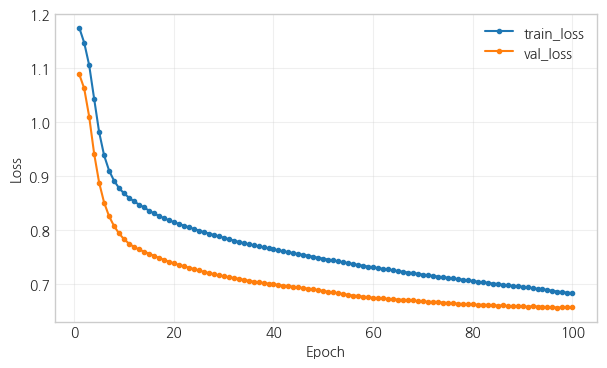

Accuracy: 0.8320

[Classification Report]
              precision    recall  f1-score   support

         0.0       0.96      0.84      0.90       214
         1.0       0.45      0.78      0.57        36

    accuracy                           0.83       250
   macro avg       0.70      0.81      0.73       250
weighted avg       0.88      0.83      0.85       250


[Confusion Matrix]
[[180  34]
 [  8  28]]


In [146]:
df = pd.read_csv(CONTENT_DIR / "Attrition_train_validation.csv")
df['Attrition'] = np.where(df['Attrition']=='Yes', 1, 0)

target = 'Attrition'
X = pd.get_dummies(df.drop(target, axis = 1), drop_first=True)
y = df.loc[:, target]

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=.2, random_state = 20)

scaler = MinMaxScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)

train_loader, X_val_ts, y_val_ts = make_DataSet(
    X_train, X_val, y_train, y_val, batch_size=8
)

n_feature = X.shape[1]

# 모델 구조 설계
model1 = nn.Sequential(
    nn.Linear(n_feature, 8),
    nn.ReLU(),
    nn.Linear(8, 1),
).to(device)

optimizer = Adam(model1.parameters(), lr=0.001)

# 0번(No) 개수 / 1번(Yes) 개수
neg_count = (y_train == 0).sum()
pos_count = (y_train == 1).sum()
pos_weight_value = neg_count / pos_count # 약 5.xxx

# 텐서 형태로 변환 (장치 설정 포함)
pos_weight = torch.tensor([pos_weight_value]).to(device)
loss_fn = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

epochs = 100
tr_loss_list, val_loss_list = [], []

for t in range(1, epochs + 1):
    tr_loss = train(train_loader, model1, loss_fn, optimizer, device)
    val_loss, _ = evaluate(X_val_ts, y_val_ts, model1, loss_fn, device)
    
    tr_loss_list.append(tr_loss)
    val_loss_list.append(val_loss)
    if t % 10 == 0:
        print(f"Epoch {t}, train loss : {tr_loss:4f}, val loss : {val_loss:4f}")

dl_learning_curve(tr_loss_list, val_loss_list)

# 예측 시 수동으로 시그모이드 적용
loss, logits = evaluate(X_val_ts, y_val_ts, model1, loss_fn, device)
pred = torch.sigmoid(logits) # 확률값으로 변환

y_pred_label = (pred >= 0.5).float()

# 텐서를 넘파이로 변환
y_true = y_val_ts.cpu().numpy()
y_pred = y_pred_label.cpu().numpy()
# 1. 정확도 출력
print(f"Accuracy: {accuracy_score(y_true, y_pred):.4f}")
# 2. 종합 리포트 (Precision, Recall, F1-score 포함)
print("\n[Classification Report]")
print(classification_report(y_true, y_pred))
# 3. 혼동 행렬 (어디서 틀렸는지 상세 확인)
print("\n[Confusion Matrix]")
print(confusion_matrix(y_true, y_pred))

In [148]:
train_dataset = datasets.MNIST(
    root="data",
    train=True,
    download=True,
    transform=ToTensor(),
)

test_dataset = datasets.MNIST(
    root="data",
    train=False,
    download=True,
    transform=ToTensor(),
)

100%|██████████| 9.91M/9.91M [00:02<00:00, 4.59MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 147kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 1.38MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 2.82MB/s]


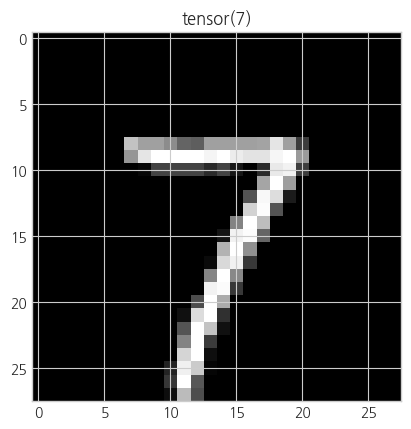

In [169]:
n = 2348
image, label = train_dataset.data[n], train_dataset.targets[n]

plt.imshow(image, cmap='gray')
plt.title(label)
plt.show()

In [172]:
batch_size = 64
train_dataloader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

X_val, X_test = test_dataset.data[:5000], test_dataset.data[5000:]
y_val, y_test = test_dataset.targets[:5000], test_dataset.targets[5000:]

# 모든 픽셀값 [0,1] 범위로 변환
X_val = X_val / 255
X_test = X_test / 255

X_val = X_val.view(5000, 1, 28, 28)     # [1 * 28 * 28 이미지 5000장] 구조로 변환
X_test = X_test.view(5000, 1, 28, 28)

n_feature = 28 * 28
n_class = 10

# 모델 구조 설계
model1 = nn.Sequential(
    nn.Flatten(),                       # 이미지를 한 줄로 펼치기
    nn.Linear(n_feature, n_class)       # 클래스 수만큼 출력
).to(device)

loss_fn = nn.CrossEntropyLoss()
optimizer = Adam(model1.parameters(), lr=0.01)

epochs = 5
tr_loss_list, val_loss_list = [], []

for t in range(epochs):
    tr_loss = train(train_dataloader, model1, loss_fn, optimizer, device)
    val_loss, _ = evaluate(X_val, y_val, model1, loss_fn, device)

    # 리스트에 loss 추가 --> learning curve 그리기 위해.
    tr_loss_list.append(tr_loss)
    val_loss_list.append(val_loss)

    print(f"Epoch {t+1}, train loss : {tr_loss:4f}, val loss : {val_loss:4f}")

Epoch 1, train loss : 0.357876, val loss : 0.360401
Epoch 2, train loss : 0.304914, val loss : 0.384572
Epoch 3, train loss : 0.298664, val loss : 0.401135
Epoch 4, train loss : 0.295984, val loss : 0.440200
Epoch 5, train loss : 0.293116, val loss : 0.404812


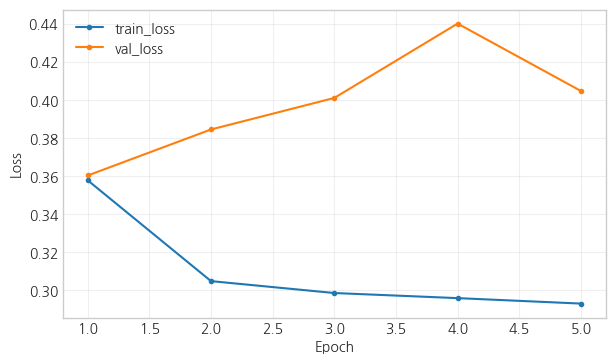

In [173]:
dl_learning_curve(tr_loss_list, val_loss_list)